In [1]:
import os
import copy
import logging
import h5py as h5
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.cm as cm



# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})


Zsun = 0.02  
threshold = 1.00 #threshold for MRR, mB > threshold * mA
# ------------------------------
# Load COMPAS data
# ------------------------------

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]

    # LVK defined M1
    m1_compas     = np.maximum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    m2_compas     = np.minimum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    
    MRR_bh_compas = (f["event_properties/mass_2"][()] > threshold *
                     f["event_properties/mass_1"][()])

    Z_compas      = f["event_properties/metallicity"][()]  
    logZrel_compas  = np.log10(Z_compas / Zsun)

    # Just ensure we are grabbing M1 and M2 ZAMS. 
    zams1_compas  = np.maximum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    zams2_compas  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    
    delay_time_compas = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_compas_binary_assumption = f["event_properties/mass_1"][()]
    m2_compas_binary_assumption = f["event_properties/mass_2"][()]

# ------------------------------
# Load SEVN data
# ------------------------------

# with h5.File("processed_yields_SEVN.h5", "r") as f:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

    m1_sevn     = np.maximum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    m2_sevn     = np.minimum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    MRR_bh_sevn = (f["event_properties/mass_2"][()] > threshold *
                   f["event_properties/mass_1"][()])

    Z_sevn      = f["event_properties/metallicity"][()]
    logZrel_sevn  = np.log10(Z_sevn / Zsun)

    zams1_sevn  = np.maximum(f["event_properties/zams_mass_1"][()],
                              f["event_properties/zams_mass_2"][()])
    zams2_sevn  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])

    delay_time_sevn = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_sevn_binary_assumption = f["event_properties/mass_1"][()]
    m2_sevn_binary_assumption = f["event_properties/mass_2"][()]


In [2]:
R_sevn = Y_sevn.sum(axis=1)
R_compas = Y_compas.sum(axis=1)

Rz_MRR_sevn= Y_sevn[:,MRR_bh_sevn].sum(axis=1)
Rz_nonMRR_sevn= Y_sevn[:,~MRR_bh_sevn].sum(axis=1)

Rz_MRR_compas= Y_compas[:,MRR_bh_compas].sum(axis=1)
Rz_nonMRR_compas= Y_compas[:,~MRR_bh_compas].sum(axis=1)

In [3]:
# Load the LVK data
data = np.load('../data/redshift_rate_data.npz')

pl_z = data['pl_z_list']
pl_rate = data['pl_rate_median']
pl_lower = data['pl_rate_lower']
pl_upper = data['pl_rate_upper']

bs_z = data['bs_z_list']
bs_rate = data['bs_rate_median']
bs_lower = data['bs_rate_lower']
bs_upper = data['bs_rate_upper']


In [4]:
def sfrd(z, a, b, c, d):
    return a * (1 + z)**b / (1 + ((1 + z) / c)**d)

a, b, c, d = 0.02, 1.49, 4.44, 5.89

z = np.linspace(0, 2, 100)

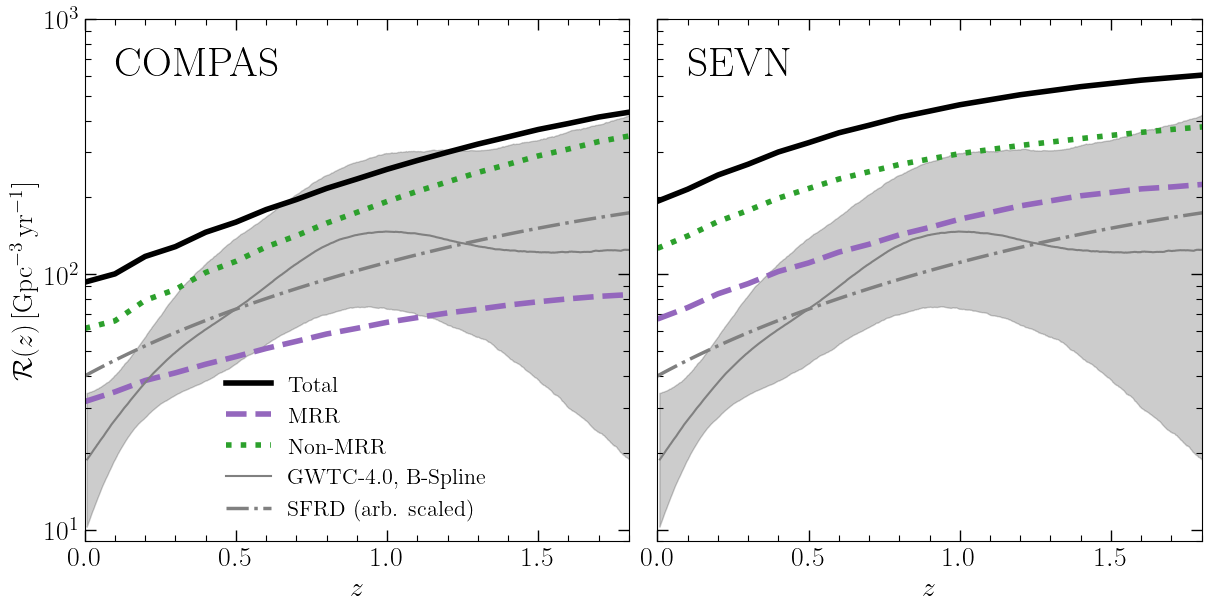

In [5]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6), constrained_layout=True)

cmrr = "#9467BD"  # purple
cnomrr = "#2CA02C"  # green

axs[0].plot(z_vals_compas, R_compas, lw=4, label='Total', c='k')
axs[0].plot(z_vals_compas, Rz_MRR_compas, lw=4, label='MRR', c=cmrr, ls='--')
axs[0].plot(z_vals_compas, Rz_nonMRR_compas, lw=4, label='Non-MRR', c=cnomrr, ls=':')
axs[0].plot(bs_z, bs_rate, color='gray', label='GWTC-4.0, B-Spline')
axs[0].fill_between(bs_z, bs_lower, bs_upper, color='k', alpha=0.2)
axs[0].plot(z, sfrd(z, a, b, c, d) * 2e3, 'gray', ls='-.', lw=2.5, label='SFRD (arb. scaled)')
axs[0].set_ylim(9, 1e3)
axs[0].set_xlim(0, 1.8)
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$\mathcal{R}(z) \, \rm [Gpc^{-3} \, yr^{-1}]$")
axs[0].set_xlabel(r"$z$")
axs[0].text(0.1, 600, "COMPAS", fontsize=30)
axs[0].legend(frameon=False, fontsize=16, loc="lower center")
axs[0].minorticks_on()

axs[1].plot(z_vals_sevn, R_sevn, lw=4, label='Total', c='k')
axs[1].plot(z_vals_sevn, Rz_MRR_sevn, lw=4, label='MRR', c=cmrr, ls='--')
axs[1].plot(z_vals_sevn, Rz_nonMRR_sevn, lw=4, label='Non-MRR', c=cnomrr, ls=':')
axs[1].plot(bs_z, bs_rate, color='gray', label='GWTC-4.0, B-Spline')
axs[1].fill_between(bs_z, bs_lower, bs_upper, color='k', alpha=0.2)
axs[1].plot(z, sfrd(z, a, b, c, d) * 2e3, 'gray', ls='-.', lw=2.5, label='SFRD (arb. scaled)')
axs[1].set_ylim(9, 1e3)
axs[1].set_xlim(0, 1.8)
axs[1].set_xlabel(r"$z$")
axs[1].text(0.1, 600, "SEVN", fontsize=30)
#axs[1].legend(frameon=False, fontsize=16, loc="lower center")
axs[1].minorticks_on()

plt.savefig("../plots/final-sidebyside-r-z-w-sfrd.pdf")
plt.show()